## Introduction

Formula One (F1) is one of the most competitive motorsports in the world, where both driver skill and car performance play a crucial role in determining race outcomes. Teams invest heavily in optimizing car design, while drivers must demonstrate precision and consistency under high-pressure conditions. As a result, understanding what factors contribute to success in Formula One is an important and interesting data analysis problem.

In this project, we investigate the relationship between qualifying performance and race results to determine whether starting position is a strong indicator of success. Specifically, we analyze whether drivers who perform well in qualifying sessions tend to achieve better final positions and earn more points in races. Using multiple datasets from Formula One race records, we merge and analyze qualifying and race results to explore this relationship. Our findings suggest that there is a strong association between qualifying position and race outcomes, although other factors such as race conditions and strategy may also influence final performance. The remainder of this report describes the data used, the methods of analysis, and the results of our findings.

## Data Description

For this analysis, we focus on understanding the relationship between qualifying performance and race results in Formula One. We use two primary datasets: the qualifying results dataset and the race results dataset. The qualifying dataset contains information about each driver's starting position for a race, while the results dataset contains information about final race outcomes, including finishing position and points earned.

To compare qualifying performance with race outcomes, the qualifying and results datasets were merged together. These two tables share the variables `raceId` and `driverId`, which uniquely identify a driver in a specific race. An inner merge was used so that only observations appearing in both datasets were kept. This allows each row in the merged table to represent one driver in one race, with both that driver’s qualifying position and final race result included in the same dataset. After merging, the relevant columns were renamed for clarity so that qualifying position and race finishing position could be distinguished more easily in the analysis.

In [5]:
import pandas as pd

qualifying = pd.read_csv("f1_data/qualifying.csv")
results = pd.read_csv("f1_data/results.csv")

qualifying_small = qualifying[["raceId", "driverId", "position"]]
results_small = results[["raceId", "driverId", "positionOrder", "points"]]

merged = pd.merge(qualifying_small, results_small, on=["raceId", "driverId"], how="inner")

merged = merged.rename(columns={
    "position": "qualifying_position",
    "positionOrder": "race_position"
})

merged.head()

,raceId,driverId,qualifying_position,race_position,points
0,18,1,1,1,10.0
1,18,9,2,9,0.0
2,18,5,3,5,4.0
3,18,13,4,13,0.0
4,18,2,5,2,8.0


After merging the datasets, several data cleaning steps were performed to ensure the dataset was suitable for analysis. First, only the relevant columns needed for this study were retained, including qualifying position, race finishing position, and points. Rows containing missing values were removed to avoid inaccuracies in the analysis. Additionally, the dataset was checked for consistency in data types, and the columns were kept in numerical form to allow for proper comparisons and calculations. These cleaning steps ensure that the dataset is accurate and ready for analyzing the relationship between qualifying performance and race outcomes.

In [7]:
# Drop missing values
merged = merged.dropna()

# Ensure numeric data types
merged["qualifying_position"] = pd.to_numeric(merged["qualifying_position"])
merged["race_position"] = pd.to_numeric(merged["race_position"])
merged["points"] = pd.to_numeric(merged["points"])

# Reset index after cleaning
merged = merged.reset_index(drop=True)

# Check cleaned data
merged.head()
merged.shape

(9395, 5)

The main columns used in this analysis are qualifying_position, race_position, and points. The qualifying_position column represents the position a driver starts in after the qualifying session, while the race_position column represents the driver’s final finishing position in the race. The points column indicates how many championship points the driver earned in that race. These columns are important because they allow us to directly compare starting performance with race outcomes. By examining these variables, we can analyze whether drivers who start in better positions tend to finish in better positions and earn more points.

In [8]:
display(merged[["qualifying_position", "race_position", "points"]].describe().round(2))

,qualifying_position,race_position,points
count,9395.00,9395.00,9395.00
mean,11.28,11.30,3.39
std,6.31,6.32,5.87
min,1.00,1.00,0.00
25%,6.00,6.00,0.00
50%,11.00,11.00,0.00
75%,17.00,17.00,5.00
max,28.00,28.00,50.00


## Results

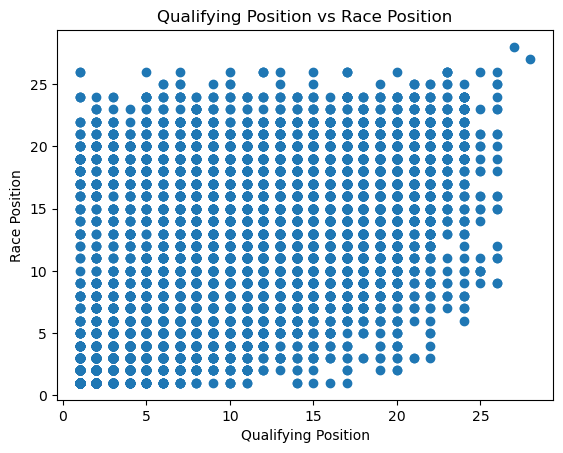

In [9]:
import matplotlib.pyplot as plt

plt.scatter(merged["qualifying_position"], merged["race_position"])
plt.xlabel("Qualifying Position")
plt.ylabel("Race Position")
plt.title("Qualifying Position vs Race Position")
plt.show()

The scatter plot shows the relationship between qualifying position and final race position. There appears to be a positive relationship, where drivers who start in better positions (lower qualifying numbers) tend to finish in better positions as well. While there is some variability, the general trend suggests that qualifying performance is an important factor in determining race outcomes.

In [10]:
merged[["qualifying_position", "race_position"]].corr()

,qualifying_position,race_position
qualifying_position,1.000000,0.566757
race_position,0.566757,1.000000


The correlation coefficient between qualifying position and race position is positive, indicating that there is a relationship between the two variables. This suggests that drivers who qualify in better positions are more likely to finish in better positions in the race. However, the correlation is not perfect, meaning that other factors such as race strategy, pit stops, and unexpected events also influence the final results.

In [11]:
avg_finish = merged.groupby("qualifying_position")["race_position"].mean()

avg_finish.head()

qualifying_position
1    4.316629
2    5.366743
3    6.232346
4    6.649203
5    8.129841
Name: race_position, dtype: float64

When grouping by qualifying position, we observe that drivers starting in higher grid positions tend to have better average finishing positions. This further supports the idea that qualifying performance plays a significant role in race outcomes.

## Discussion

In this analysis, we examined the relationship between qualifying position and race performance in Formula One. The results show a clear positive relationship between qualifying position and final race position, indicating that drivers who start in better positions are more likely to finish in better positions. This trend was supported both visually through the scatter plot and numerically through the correlation analysis, suggesting that qualifying performance is an important factor in race outcomes.

However, the relationship is not perfect, which indicates that other factors also influence race results. Elements such as race strategy, pit stops, mechanical issues, and driver decisions during the race can all impact final performance. Overall, this analysis highlights the importance of qualifying while also demonstrating that success in Formula One is influenced by multiple factors beyond just starting position.